In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('winequality-red.csv', sep=',')
print("Shape :", df.shape)
print("First 10 Data  :", df.head())
print("Data Types: ", df.dtypes)
print("Data Description" ,df.describe())

Shape : (1599, 12)
First 10 Data  :    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1     

In [2]:
#Missing Data Analysis
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


Text(0.5, 1.0, 'Distribution of wine quality scores')

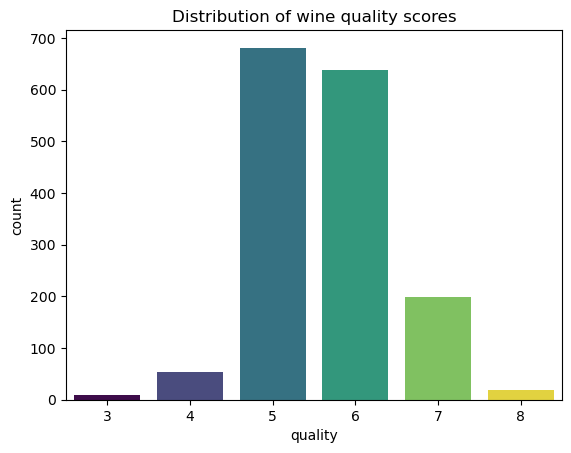

In [3]:
#Target Variable distribution

sns.countplot(x='quality', data=df, hue='quality', legend=False, palette='viridis')
plt.title('Distribution of wine quality scores')

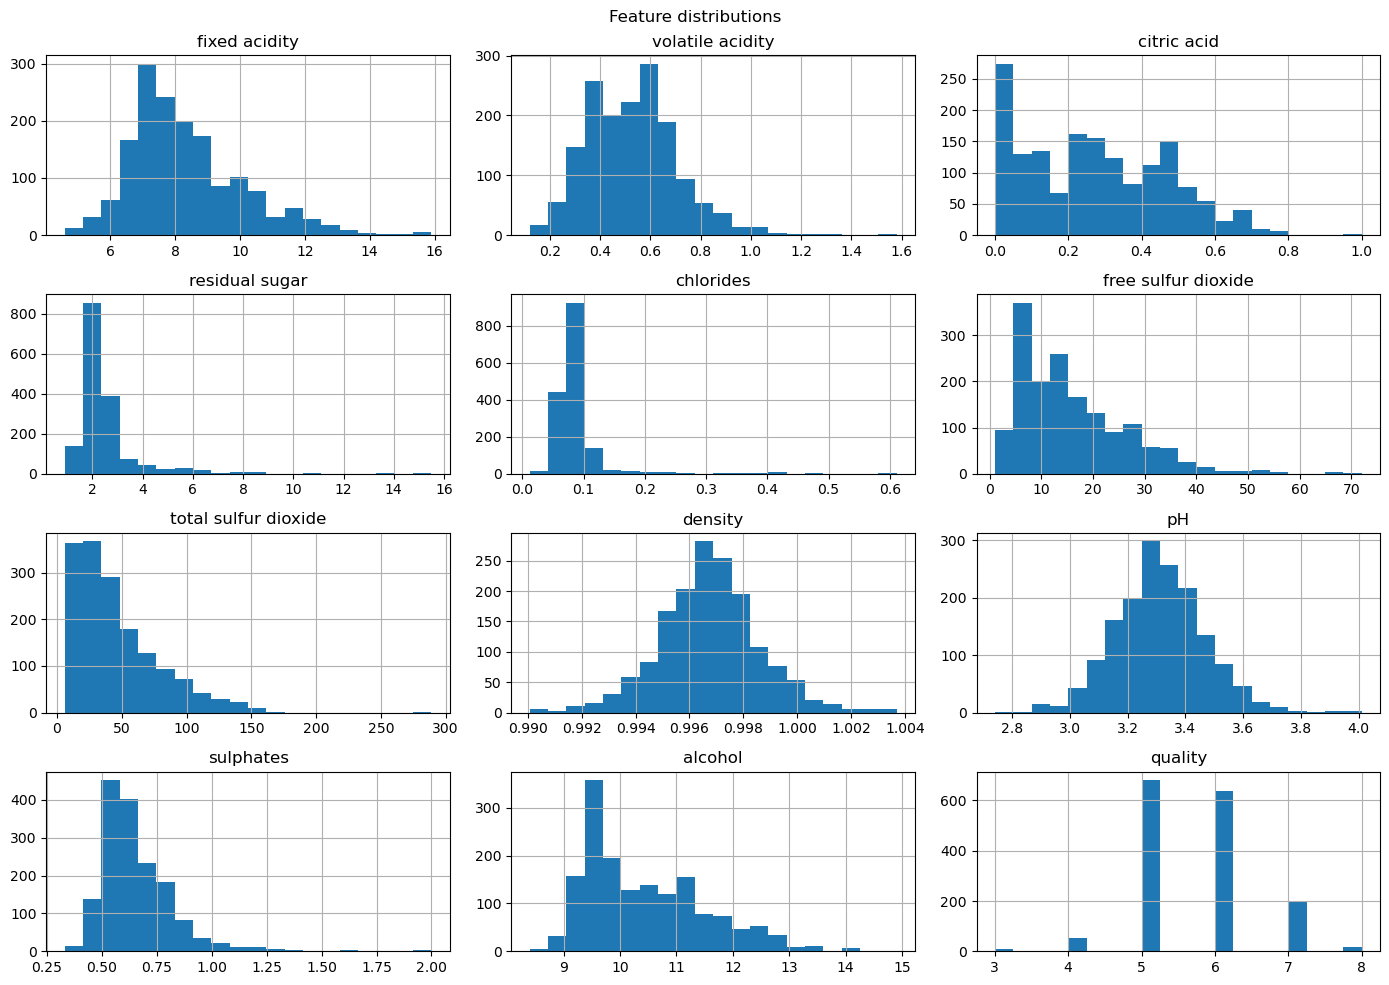

In [4]:
#Feature Distributions
df.hist(bins=20, figsize=(14, 10))
plt.suptitle('Feature distributions')
plt.tight_layout()

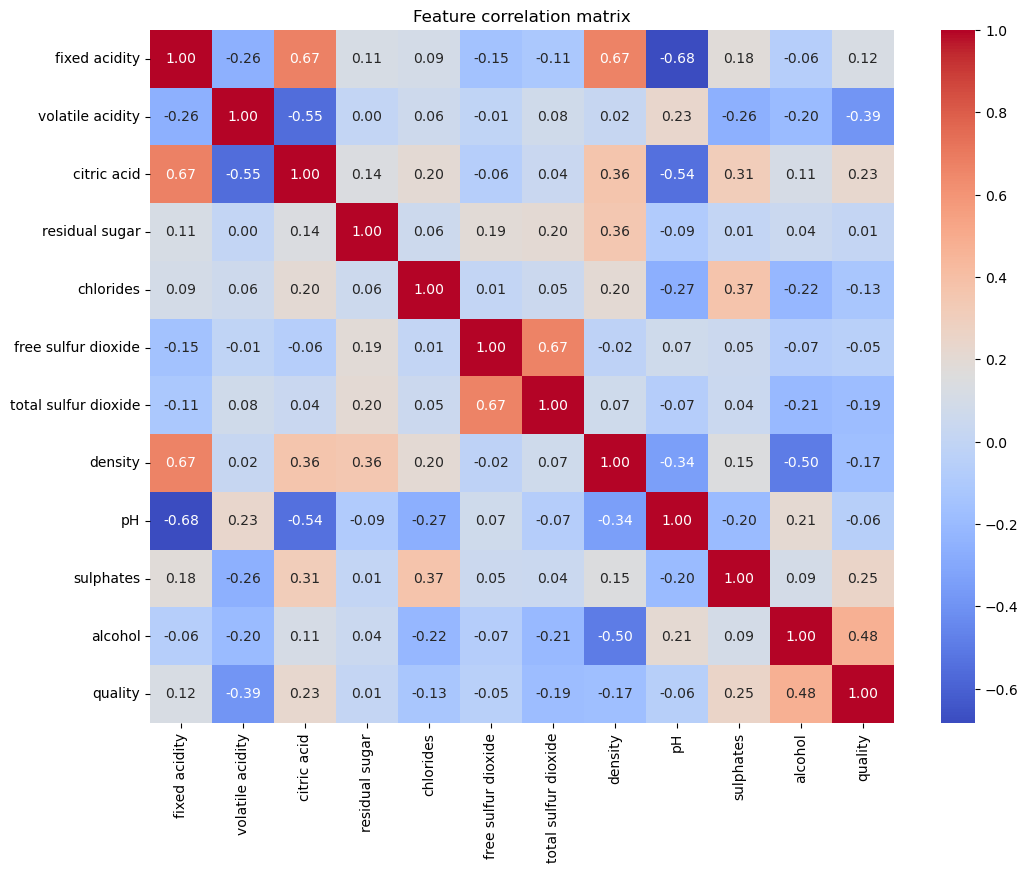

In [5]:
#Correlation heat map
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature correlation matrix')
plt.savefig('correlation_heatmap.png')

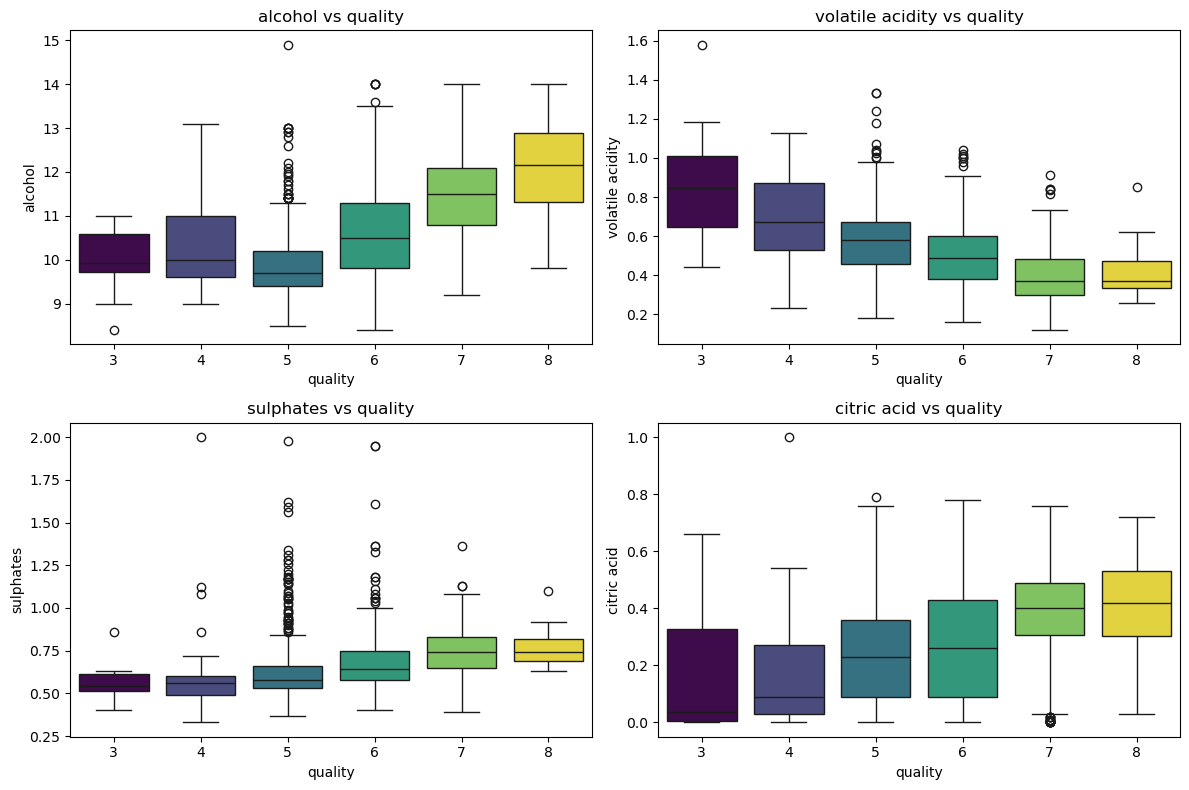

In [17]:
#Boxplot top features vs quality
top_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), top_features):
    sns.boxplot(x='quality', y=feat, data=df, hue='quality', legend=False, ax=ax, palette='viridis')
    ax.set_title(f'{feat} vs quality')
plt.tight_layout()
plt.savefig('boxplots_top_features.png')

In [7]:
#Outlier detection
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
print(outliers)

fixed acidity            49
volatile acidity         19
citric acid               1
residual sugar          155
chlorides               112
free sulfur dioxide      30
total sulfur dioxide     55
density                  45
pH                       35
sulphates                59
alcohol                  13
quality                  28
dtype: int64


In [8]:
#Processing Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop('quality', axis=1)
y = df['quality']

#Stratify=y ensuring class imbalance is preserved
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Training set: (1279, 11)
Test set: (320, 11)


In [9]:
#Logistic Regression - Baseline Model

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
from sklearn.ensemble import RandomForestClassifier
#Random Forest - Primary Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
#Hyperparameter turning with GridSearchCV

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

rf_best = grid_search.best_estimator_

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Best CV score: 0.6652084568697976


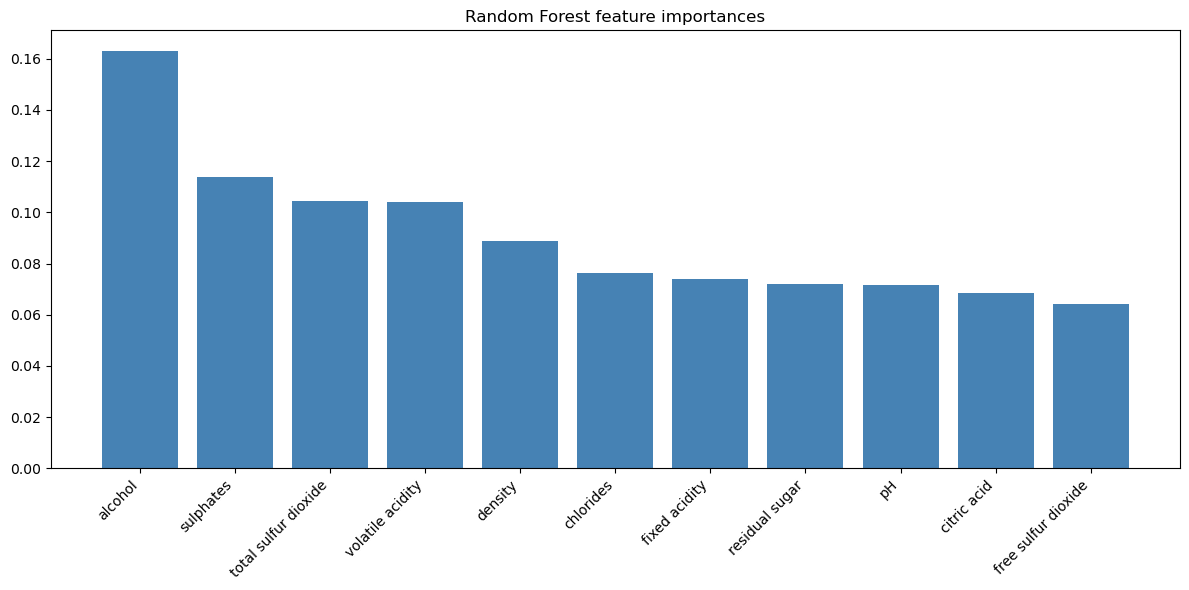

In [12]:
#Feature importance plot

importances = rf_best.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), importances[indices], color='steelblue')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Random Forest feature importances')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [18]:
#Predictions and Classification Reports
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, accuracy_score

# Logistic Regression
lr_preds = lr.predict(X_test_scaled)

# Tuned Random Forest
rf_preds = rf_best.predict(X_test_scaled)

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds, zero_division=0))

print("=== Random Forest (Tuned) ===")
print(classification_report(y_test, rf_preds, zero_division=0))

=== Logistic Regression ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320

=== Random Forest (Tuned) ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.63      0.73      0.68       128
           7       0.78      0.53      0.63        40
           8       0.00      0.00      0.00         3

    accuracy       

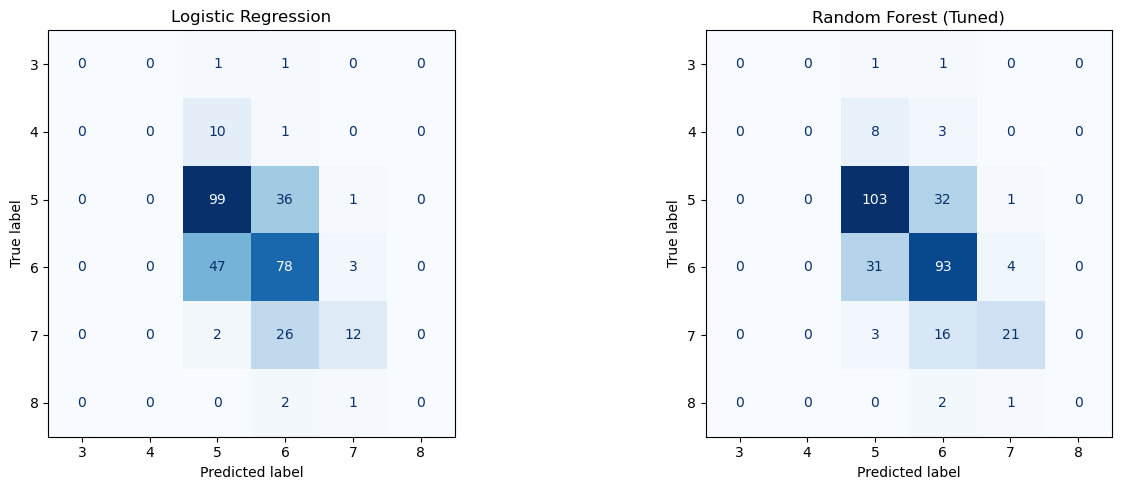

In [14]:
#Confusion Matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_preds, ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_preds, ax=axes[1], colorbar=False, cmap='Blues'
)
axes[1].set_title('Random Forest (Tuned)')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

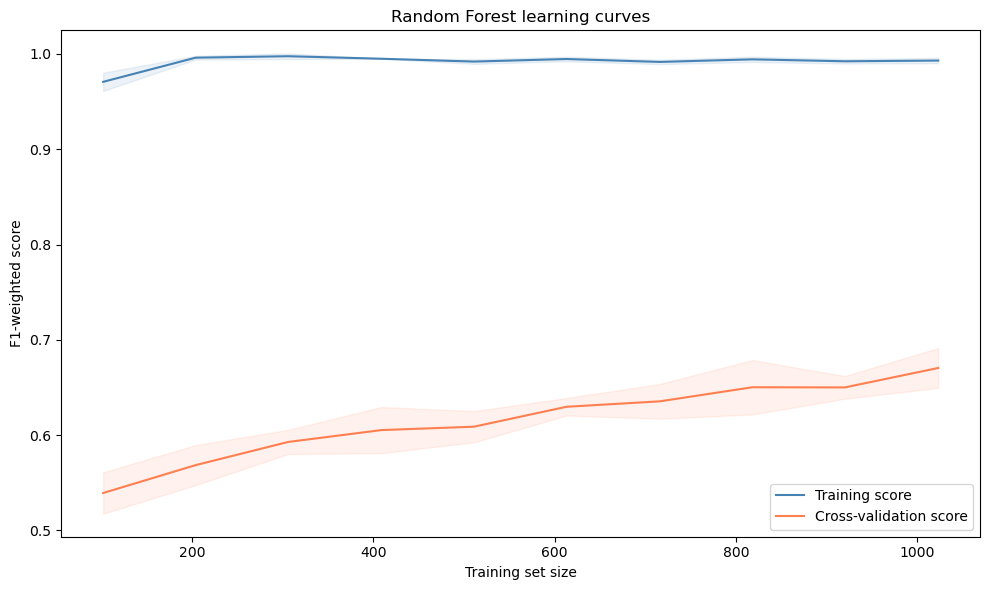

In [15]:
#learning Curves

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    rf_best, X_train_scaled, y_train,
    cv=5, scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training score', color='steelblue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='steelblue')
plt.plot(train_sizes, val_mean, label='Cross-validation score', color='coral')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='coral')
plt.xlabel('Training set size')
plt.ylabel('F1-weighted score')
plt.title('Random Forest learning curves')
plt.legend()
plt.tight_layout()
plt.savefig('learning_curves.png')
plt.show()

In [16]:
#Summary metrics table

results = {
    'Model': ['Logistic Regression', 'Random Forest (Tuned)'],
    'Accuracy': [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds)
    ],
    'F1-Weighted': [
        f1_score(y_test, lr_preds, average='weighted'),
        f1_score(y_test, rf_preds, average='weighted')
    ],
    'F1-Macro': [
        f1_score(y_test, lr_preds, average='macro'),
        f1_score(y_test, rf_preds, average='macro')
    ]
}

results_df = pd.DataFrame(results)
print(results_df.round(4))

                   Model  Accuracy  F1-Weighted  F1-Macro
0    Logistic Regression    0.5906       0.5673    0.2776
1  Random Forest (Tuned)    0.6781       0.6594    0.3390
